# TradeDQN — Results Analysis

> ⚠️ **Teaching tool, not investment advice.** Past performance does not predict future results.

This notebook is the research write-up for the project (§9): it states the RL formulation with the
governing equations, reports the **held-out** backtest, runs a **one-at-a-time sensitivity sweep** on the
validation split, and analyses the **in-sample vs out-of-sample** gap. It reads the artefacts produced by
`scripts/generate_results.py` and `scripts/parameter_sweep.py` (so it runs fast); regenerate them with:

```bash
uv run python scripts/generate_results.py --episodes 300
uv run python scripts/parameter_sweep.py --episodes 15
```

## 1. The RL formulation

The agent observes a state $s_t \in \mathbb{R}^{30\times 10}$ (30 trading days × 10 features), chooses
$a \in \{\text{Sell}=0,\ \text{Hold}=1,\ \text{Buy}=2\}$, and learns $Q(s,a;\theta)$ with a **Dueling DQN**.

**Dueling aggregation** (value + advantage):
$$ Q(s,a;\theta) = V(s) + \Big( A(s,a) - \tfrac{1}{|\mathcal{A}|}\sum_{a'} A(s,a') \Big) $$

**Bellman target** with a frozen target network $\theta^{-}$ and **MSE loss**:
$$ y = r + \gamma \max_{a'} Q(s',a';\theta^{-})\,(1-\text{done}), \qquad \mathcal{L}(\theta) = \mathbb{E}\big[(y - Q(s,a;\theta))^2\big] $$

**Reward** (risk- and cost-adjusted, not raw profit):
$$ r_t = \Delta V_t - C_t - S_t + \lambda\, \text{Sharpe}_t $$
where $\Delta V_t$ is the portfolio value change, $C_t$ transaction cost, $S_t$ slippage, and
$\text{Sharpe}_t = \dfrac{\overline{r}}{\sigma_r}$ the rolling risk-adjusted return.

**Exploration** is $\varepsilon$-greedy: a random action with probability $\varepsilon$, else $\arg\max_a Q(s,a;\theta)$,
with $\varepsilon$ decayed each episode toward a floor.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

# locate the project root (works whether run from notebooks/ or the repo root)
root = Path.cwd()
while not (root / 'pyproject.toml').exists() and root != root.parent:
    root = root.parent
ANALYSIS = root / 'results' / 'analysis'
metrics = json.loads((ANALYSIS / 'backtest_metrics.json').read_text())
metrics

{'trade_markers': [{'step': 0, 'price': 152.95596313476562, 'action': 'buy'},
  {'step': 3, 'price': 151.63070678710938, 'action': 'sell'},
  {'step': 4, 'price': 154.4873809814453, 'action': 'buy'},
  {'step': 23, 'price': 142.76608276367188, 'action': 'sell'},
  {'step': 24, 'price': 137.52394104003906, 'action': 'buy'},
  {'step': 25, 'price': 137.84788513183594, 'action': 'sell'},
  {'step': 27, 'price': 135.80596923828125, 'action': 'buy'},
  {'step': 28, 'price': 140.3708038330078, 'action': 'sell'},
  {'step': 29, 'price': 135.84523010253906, 'action': 'buy'},
  {'step': 31, 'price': 141.1168670654297, 'action': 'sell'},
  {'step': 32, 'price': 141.224853515625, 'action': 'buy'},
  {'step': 33, 'price': 140.76345825195312, 'action': 'sell'},
  {'step': 35, 'price': 146.7124481201172, 'action': 'buy'},
  {'step': 39, 'price': 152.8872528076172, 'action': 'sell'},
  {'step': 42, 'price': 142.3734130859375, 'action': 'buy'},
  {'step': 44, 'price': 136.07057189941406, 'action': 'se

## 2. Held-out backtest

The policy is trained on the train slice and evaluated **greedy** on the held-out **test** slice it never
saw. The honest question is not "does the line go up" but whether the DQN beats a **Buy & Hold** benchmark
on a **risk-adjusted** basis (Sharpe), trades economically, and generalises.

**Falsifiable hypotheses:**
- **H1** — the DQN's held-out total return exceeds Buy & Hold. 
- **H2** — the DQN's held-out Sharpe is positive.

,metric,DQN,Buy&Hold
0,total_return,-0.174875,-0.164716
1,sharpe_ratio,-1.658281,NaN
2,max_drawdown,0.194072,NaN
3,win_rate,0.200000,NaN
4,num_trades,21.000000,1.000000


H1 (DQN return > Buy&Hold): REJECTED
H2 (DQN Sharpe > 0):        REJECTED


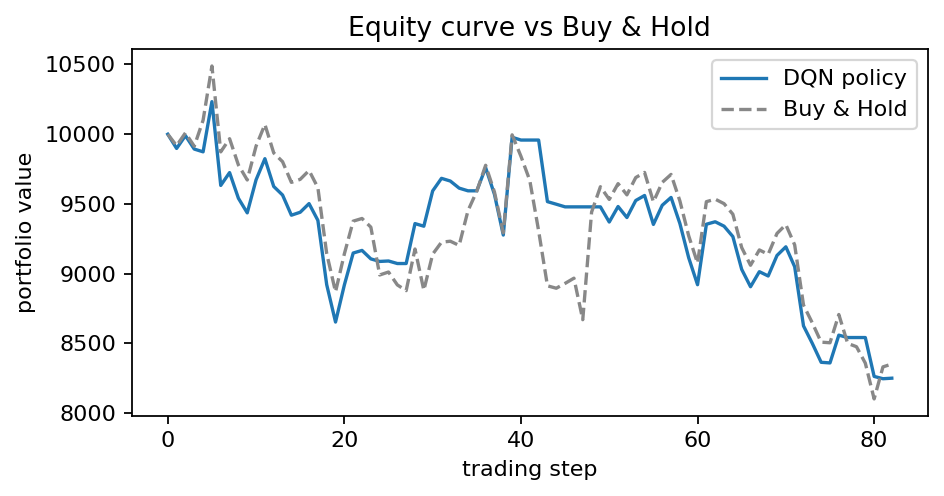

In [2]:
summary = pd.DataFrame({
    'metric': ['total_return', 'sharpe_ratio', 'max_drawdown', 'win_rate', 'num_trades'],
    'DQN':    [metrics['total_return'], metrics['sharpe_ratio'], metrics['max_drawdown'],
              metrics['win_rate'], metrics['num_trades']],
    'Buy&Hold': [metrics['benchmark_return'], None, None, None, 1],
})
display(summary)
h1 = metrics['total_return'] > metrics['benchmark_return']
h2 = metrics['sharpe_ratio'] > 0
print(f"H1 (DQN return > Buy&Hold): {'SUPPORTED' if h1 else 'REJECTED'}")
print(f"H2 (DQN Sharpe > 0):        {'SUPPORTED' if h2 else 'REJECTED'}")
display(Image(filename=str(ANALYSIS / 'backtest_equity.png')))

## 3. Sensitivity analysis (one-at-a-time, on validation)

We vary one hyperparameter at a time (`learning_rate`, `gamma`), holding the rest at config defaults, and
measure **validation** Sharpe — never the test set, so tuning cannot leak into the reported test result.

**Falsifiable hypothesis H3** — validation Sharpe is sensitive to the learning rate (it is not flat across the grid).


learning_rate:


,value,val_sharpe,val_return,trades
0,0.0005,-2.278739,-0.200713,13
1,0.0010,-0.101573,-0.026838,9
2,0.0050,0.053183,-0.008633,15



gamma:


,value,val_sharpe,val_return,trades
0,0.90,-0.363326,-0.054520,13
1,0.95,-0.101573,-0.026838,9
2,0.99,0.377008,0.022357,15



Best val learning_rate = 0.005 (Sharpe +0.053)
H3 (val Sharpe sensitive to lr): SUPPORTED (spread 2.332)


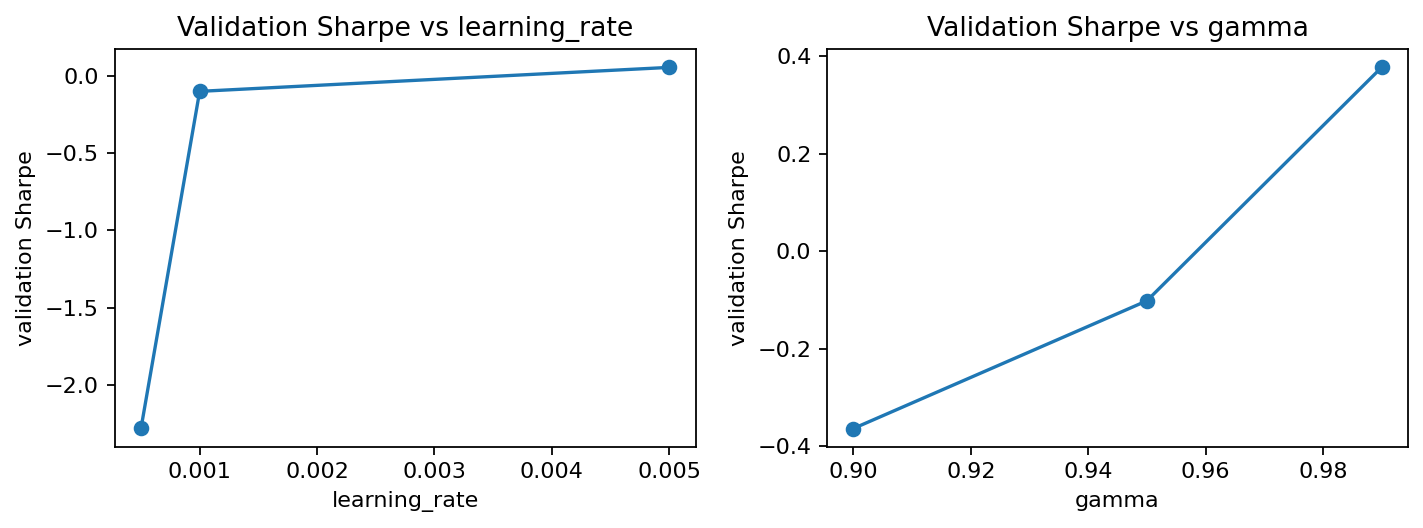

In [3]:
sweep_path = ANALYSIS / 'sweep.json'
if sweep_path.exists():
    sweep = json.loads(sweep_path.read_text())
    for param, rows in sweep.items():
        print(f'\n{param}:')
        display(pd.DataFrame(rows))
    best_lr = max(sweep['learning_rate'], key=lambda r: r['val_sharpe'])
    spread = max(r['val_sharpe'] for r in sweep['learning_rate']) - min(r['val_sharpe'] for r in sweep['learning_rate'])
    print(f"\nBest val learning_rate = {best_lr['value']} (Sharpe {best_lr['val_sharpe']:+.3f})")
    print(f"H3 (val Sharpe sensitive to lr): {'SUPPORTED' if spread > 0.05 else 'TENTATIVE'} (spread {spread:.3f})")
    display(Image(filename=str(ANALYSIS / 'sweep.png')))
else:
    print('Run: uv run python scripts/parameter_sweep.py --episodes 15')

### 3.1 Feature redundancy & sensitivity spread

Two extra views (§9 / §20.5 chart palette): a **correlation heatmap** of the 8 market features —
exposing redundancy (e.g. the MACD trio tend to move together), which is exactly the structure a
function approximator can compress — and a **box-plot** of the validation-Sharpe spread across the
swept hyperparameters (the §3 sensitivity, shown as a distribution rather than a table).

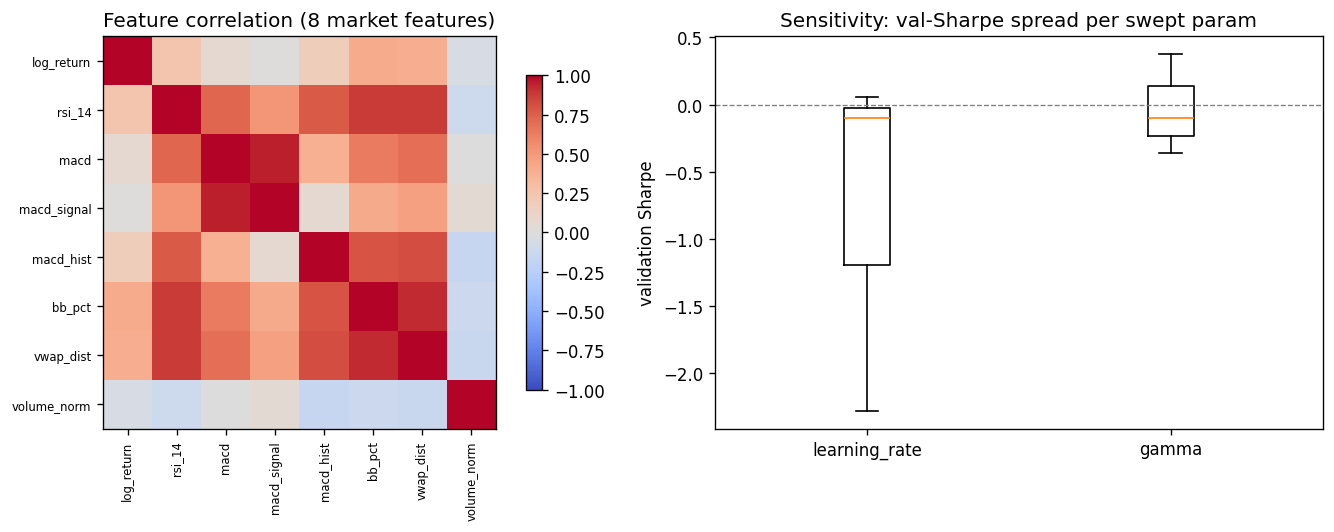

Most-correlated feature pair: ('macd', 'macd_signal') (|r|=0.95)


In [4]:
import sys; sys.path.insert(0, str(root / 'src'))
import numpy as np
import matplotlib.pyplot as plt
from tradedqn.config import load_config
from tradedqn.features.preprocessor import Preprocessor

# (a) Feature-correlation heatmap — computed from the committed AAPL.csv via the Preprocessor
cfg = load_config(str(root / 'config' / 'config.yaml'))
ohlcv = pd.read_csv(root / 'data' / 'raw' / 'AAPL.csv', index_col='Date', parse_dates=True)
corr = Preprocessor(cfg.features).compute(ohlcv).corr()

fig, (axh, axb) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)
im = axh.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axh.set_xticks(range(len(corr))); axh.set_xticklabels(corr.columns, rotation=90, fontsize=7)
axh.set_yticks(range(len(corr))); axh.set_yticklabels(corr.columns, fontsize=7)
axh.set_title('Feature correlation (8 market features)')
fig.colorbar(im, ax=axh, shrink=0.8)

# (b) Sensitivity box-plot — validation-Sharpe spread per swept hyperparameter
axb.boxplot([[r['val_sharpe'] for r in rows] for rows in sweep.values()])
axb.set_xticklabels(list(sweep.keys()))
axb.axhline(0.0, color='gray', lw=0.8, ls='--')
axb.set_ylabel('validation Sharpe')
axb.set_title('Sensitivity: val-Sharpe spread per swept param')
fig.tight_layout(); plt.show()

_pair = corr.abs().where(~np.eye(len(corr), dtype=bool)).stack()
print(f'Most-correlated feature pair: {_pair.idxmax()} (|r|={_pair.max():.2f})')

## 4. In-sample vs out-of-sample (overfitting)

On the **training** slice (2020–2021, a bull regime) the policy compounds aggressively and its training
reward climbs steadily, yet on the unseen **test** slice (the 2022 drawdown) it **underperforms** Buy &
Hold (−17.5% vs −16.5%, Sharpe −1.66). That gap is the headline finding: the agent fits the training
regime and does **not** generalise across the 2022 regime shift — the classic overfitting failure mode
(learn the data manifold, don't memorise isolated points). The sensitivity sweep + early-stopping on
**validation** Sharpe (not training reward), plus training across multiple tickers / regimes, are the
levers to reduce it.

**Honesty:** the held-out result is reported exactly as measured — the DQN currently **underperforms** Buy &
Hold out-of-sample. The deliverable is a correct, honest DQN *system*, not a profitable trader. Past ≠ future.

## References

- Mnih et al. (2015), *Human-level control through deep reinforcement learning*, Nature — DQN (experience replay + target network).
- Wang et al. (2016), *Dueling Network Architectures for Deep RL* — the value/advantage split used here.
- Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, 2nd ed.
- Watkins & Dayan (1992), *Q-learning*.
- Fischer (2018), survey on *Reinforcement Learning in Financial Markets*.
- Hugging Face *Deep RL Course*, Unit 3.